# Air Quality EDA — 34 Tỉnh Thành Việt Nam
**Mục tiêu:** Thăm dò dữ liệu thô từ MinIO (Bronze layer) để rút ra insights phục vụ:
- Data validation rules
- Preprocessing strategy cho time series forecasting (Mamba model)

**Pipeline:** `Bronze (MinIO)` → EDA → Rules → `data_validation.py` → `data_processing.py`

## 0. Setup & Load Data

In [2]:
import io
import os
import warnings
import json
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from minio import Minio

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── MinIO config ─────────────────────────────────────────────────────────────
MINIO_HOST   = os.environ.get('MINIO_HOST',       'localhost:9004')
MINIO_ACCESS = os.environ.get('MINIO_ACCESS_KEY', 'admin')
MINIO_SECRET = os.environ.get('MINIO_SECRET_KEY', 'admin123')
MINIO_BUCKET = os.environ.get('MINIO_BUCKET',     'air-quality')

METRIC_COLS = ['pm25','pm10','no2','o3','so2','co','aod','dust','uv_index','co2','aqi']
REQUIRED_COLS = ['time','location','latitude','longitude'] + METRIC_COLS

In [3]:
def load_all_bronze(years: list, months: list = None) -> pd.DataFrame:
    """Load toàn bộ Bronze data từ MinIO theo nhiều năm."""
    
    client = Minio(
        MINIO_HOST,
        access_key=MINIO_ACCESS,
        secret_key=MINIO_SECRET,
        secure=False
    )

    months = months or list(range(1, 13))
    frames = []

    objects = list(
        client.list_objects(
            MINIO_BUCKET,
            prefix='air_quality/',
            recursive=True
        )
    )

    total = len(objects)
    print(f'Found {total} objects in MinIO')

    for i, obj in enumerate(objects):

        parts = obj.object_name.split('/')

        try:
            yr = int(next(p for p in parts if p.startswith('year=')).split('=')[1])
            mo = int(next(p for p in parts if p.startswith('month=')).split('=')[1])

        except (StopIteration, ValueError):
            continue

        # filter year + month
        if yr not in years or mo not in months:
            continue

        resp = client.get_object(MINIO_BUCKET, obj.object_name)

        try:
            df = pd.read_csv(io.BytesIO(resp.read()))
            frames.append(df)

        finally:
            resp.close()
            resp.release_conn()

        if (i + 1) % 50 == 0:
            print(f'  Loaded {i+1}/{total} objects...')

    if not frames:
        raise ValueError('Không có data nào được load!')

    df = pd.concat(frames, ignore_index=True)

    df['time'] = pd.to_datetime(
        df['time'],
        utc=True,
        errors='coerce'
    )

    df = df.sort_values(
        ['location', 'time']
    ).reset_index(drop=True)

    print(f'\n✅ Loaded: {len(df):,} rows | {df["location"].nunique()} locations')
    print(f'   Date range: {df["time"].min()} → {df["time"].max()}')

    return df
df = load_all_bronze(years=[2025, 2026])
df.head(3)

Found 17510 objects in MinIO
  Loaded 50/17510 objects...
  Loaded 100/17510 objects...
  Loaded 150/17510 objects...
  Loaded 200/17510 objects...
  Loaded 250/17510 objects...
  Loaded 300/17510 objects...
  Loaded 350/17510 objects...
  Loaded 400/17510 objects...
  Loaded 450/17510 objects...
  Loaded 500/17510 objects...
  Loaded 550/17510 objects...
  Loaded 600/17510 objects...
  Loaded 650/17510 objects...
  Loaded 700/17510 objects...
  Loaded 750/17510 objects...
  Loaded 800/17510 objects...
  Loaded 850/17510 objects...
  Loaded 900/17510 objects...
  Loaded 950/17510 objects...
  Loaded 1000/17510 objects...
  Loaded 1050/17510 objects...
  Loaded 1100/17510 objects...
  Loaded 1150/17510 objects...
  Loaded 1200/17510 objects...
  Loaded 1250/17510 objects...
  Loaded 1300/17510 objects...
  Loaded 1350/17510 objects...
  Loaded 1400/17510 objects...
  Loaded 1450/17510 objects...
  Loaded 1500/17510 objects...
  Loaded 1550/17510 objects...
  Loaded 1600/17510 objects...

,time,pm25,pm10,no2,o3,so2,co,aod,dust,uv_index,co2,aqi,location,latitude,longitude
0,2024-12-31 17:00:00+00:00,25.40,25.60,13.20,45.00,9.80,416.00,0.18,0.00,0.00,470,77,an_giang,10.00,105.10
1,2024-12-31 18:00:00+00:00,18.60,18.70,10.70,47.00,7.90,384.00,0.14,0.00,0.00,468,75,an_giang,10.00,105.10
2,2024-12-31 19:00:00+00:00,14.30,14.30,9.40,48.00,6.90,351.00,0.12,0.00,0.00,467,71,an_giang,10.00,105.10


---
## 1. Missing Values Analysis
**Mục tiêu:** Xác định tỷ lệ thiếu, pattern thiếu (random hay có cấu trúc), và ngưỡng chấp nhận được.

In [4]:
# ── 1.1 Tổng quan missing rate ────────────────────────────────────────────────
missing = df[METRIC_COLS].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

miss_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('=== Missing Values Summary ===')
print(miss_df)
print(f'\n⚠️  Columns >20% missing: {list(miss_df[miss_df.missing_pct > 20].index)}')
print(f'⚠️  Columns >50% missing: {list(miss_df[miss_df.missing_pct > 50].index)}')

=== Missing Values Summary ===
          missing_count  missing_pct
pm25                  0         0.00
pm10                  0         0.00
no2                   0         0.00
o3                    0         0.00
so2                   0         0.00
co                    0         0.00
aod                   0         0.00
dust                  0         0.00
uv_index              0         0.00
co2                   0         0.00
aqi                   0         0.00

⚠️  Columns >20% missing: []
⚠️  Columns >50% missing: []


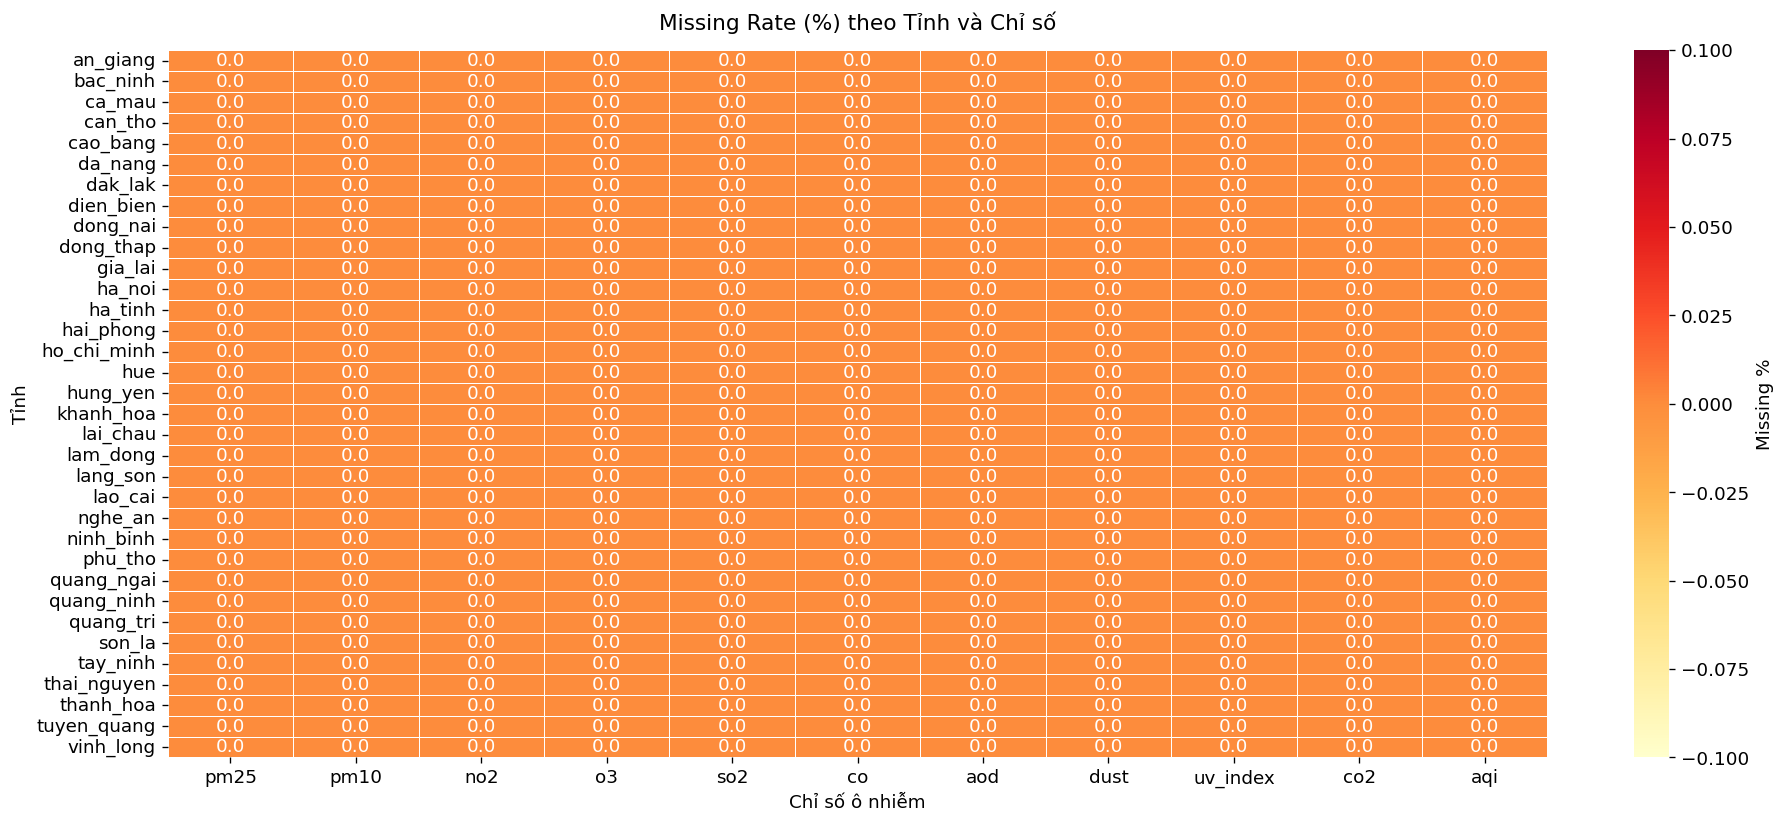


📍 Top 5 tỉnh missing AQI nhiều nhất:
location
an_giang   0.00
bac_ninh   0.00
ca_mau     0.00
can_tho    0.00
cao_bang   0.00
Name: aqi, dtype: float64


In [5]:
# ── 1.2 Missing rate theo từng tỉnh ──────────────────────────────────────────
miss_by_loc = df.groupby('location')[METRIC_COLS].apply(
    lambda x: x.isnull().mean() * 100
).round(2)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(miss_by_loc, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Missing %'})
ax.set_title('Missing Rate (%) theo Tỉnh và Chỉ số', fontsize=13, pad=12)
ax.set_xlabel('Chỉ số ô nhiễm')
ax.set_ylabel('Tỉnh')
plt.tight_layout()
plt.savefig('missing_heatmap.png', bbox_inches='tight')
plt.show()

# Tỉnh có vấn đề nhất
worst_locations = miss_by_loc['aqi'].nlargest(5)
print(f'\n📍 Top 5 tỉnh missing AQI nhiều nhất:\n{worst_locations}')

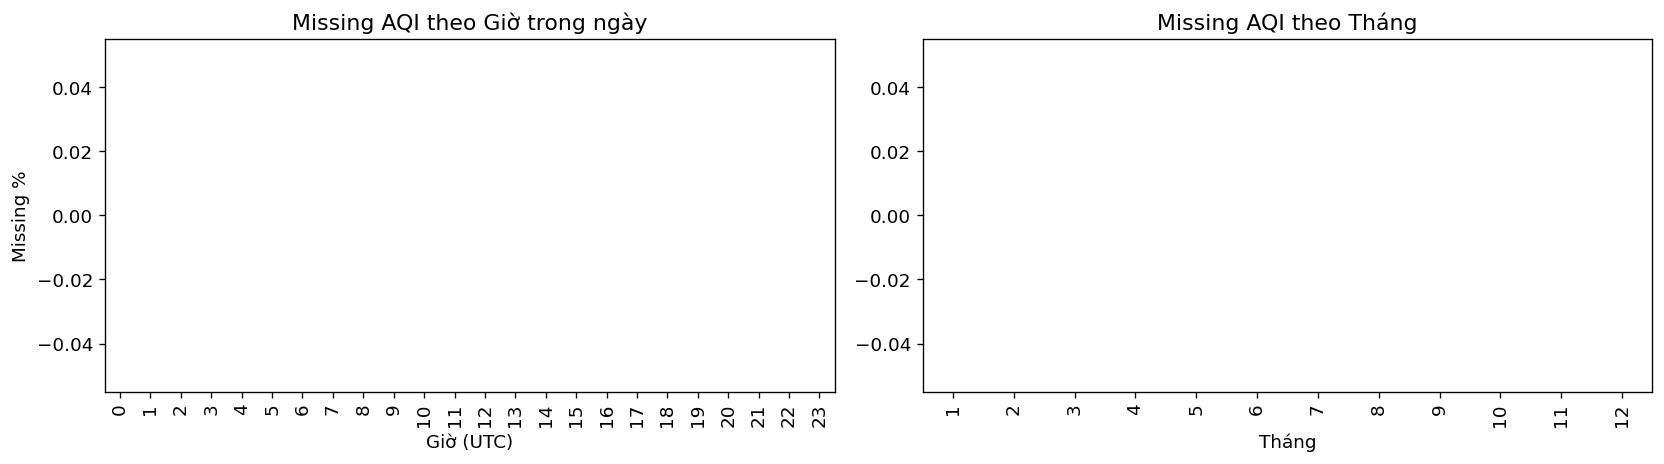


📋 INSIGHT — Missing Values:
  • Cột missing nhiều nhất : pm25 (0.0%)
  • Cột vượt ngưỡng 30%    : Không có
  • Median missing rate    : 0.0%  → threshold đề xuất: 0.0%
  • Pattern theo giờ: RANDOM (std=0.0%) → impute bằng linear interpolation
  • Tháng missing nhiều nhất: tháng 1 (0.0%)


In [ ]:
# ── 1.3 Missing pattern: random hay có cấu trúc? ─────────────────────────────
df['hour'] = df['time'].dt.hour
miss_by_hour = df.groupby('hour')['aqi'].apply(lambda x: x.isnull().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_by_hour.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Missing AQI theo Giờ trong ngày')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('Missing %')

df['month'] = df['time'].dt.month
miss_by_month = df.groupby('month')['aqi'].apply(lambda x: x.isnull().mean() * 100)
miss_by_month.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Missing AQI theo Tháng')
axes[1].set_xlabel('Tháng')
plt.tight_layout()
plt.savefig('missing_pattern.png', bbox_inches='tight')
plt.show()

# ── Tính từ data: cột nào missing nhiều nhất? ────────────────────────────────
worst_col        = miss_df['missing_pct'].idxmax()
worst_col_pct    = miss_df['missing_pct'].max()
cols_above_30    = list(miss_df[miss_df['missing_pct'] > 30].index)

# Pattern theo giờ: std cao → có cấu trúc, std thấp → random
hour_std         = miss_by_hour.std()
hour_peak        = int(miss_by_hour.idxmax())
is_structured    = hour_std > 2.0   # ngưỡng: std > 2% → có pattern

# Pattern theo tháng
month_peak       = int(miss_by_month.idxmax())
month_peak_pct   = miss_by_month.max()

# Recommended threshold: 1.5x median missing rate, capped at 30%
median_miss      = miss_df['missing_pct'].median()
recommended_thr  = round(min(median_miss * 1.5, 30.0), 1)

print('\n📋 INSIGHT — Missing Values:')
print(f'  • Cột missing nhiều nhất : {worst_col} ({worst_col_pct:.1f}%)')
print(f'  • Cột vượt ngưỡng 30%    : {cols_above_30 if cols_above_30 else "Không có"}')
print(f'  • Median missing rate    : {median_miss:.1f}%  → threshold đề xuất: {recommended_thr}%')
if is_structured:
    print(f'  • Pattern theo giờ: CÓ CẤU TRÚC (std={hour_std:.1f}%, peak tại giờ {hour_peak}h)')
    print( '    → Sensor issue: nên FLAG, không nên impute')
else:
    print(f'  • Pattern theo giờ: RANDOM (std={hour_std:.1f}%) → impute bằng linear interpolation')
print(f'  • Tháng missing nhiều nhất: tháng {month_peak} ({month_peak_pct:.1f}%)')


---
## 2. Duplicate Timestamp Check
**Mục tiêu:** Phát hiện timestamp bị trùng trong cùng một location — ảnh hưởng nghiêm trọng đến time series model.

In [7]:
# ── 2.1 Tổng số duplicate ─────────────────────────────────────────────────────
dup_mask = df.duplicated(subset=['time','location'], keep=False)
dup_df   = df[dup_mask]

n_dup_rows = dup_mask.sum()
n_dup_pairs = n_dup_rows // 2
print(f'Tổng duplicate (time, location): {n_dup_rows:,} rows')
print(f'Số cặp bị dup: {n_dup_pairs:,}')

if not dup_df.empty:
    print('\nVí dụ duplicate:')
    print(dup_df[['time','location','aqi']].head(10))

# ── 2.2 Duplicate theo tỉnh ───────────────────────────────────────────────────
dup_by_loc = (
    df.groupby('location')
    .apply(lambda x: x.duplicated(subset=['time'], keep=False).sum())
    .sort_values(ascending=False)
)
locs_with_dup = dup_by_loc[dup_by_loc > 0]
print('\nDuplicate count theo tỉnh:')
print(locs_with_dup if not locs_with_dup.empty else '  Không có tỉnh nào bị duplicate')

# ── INSIGHT tính từ data ──────────────────────────────────────────────────────
dup_rate = n_dup_rows / len(df) * 100
worst_dup_loc = dup_by_loc.idxmax() if not locs_with_dup.empty else None
worst_dup_n   = dup_by_loc.max()    if not locs_with_dup.empty else 0

print('\n📋 INSIGHT — Duplicate Timestamps:')
print(f'  • Tổng duplicate: {n_dup_rows:,} rows ({dup_rate:.2f}% tổng data)')
if worst_dup_loc:
    print(f'  • Tỉnh dup nhiều nhất: {worst_dup_loc} ({worst_dup_n:,} rows)')
else:
    print('  • Không phát hiện duplicate trong data')
print('  • Rule: drop_duplicates(subset=[time, location], keep=last)')
print('  • Reason: keep=last vì row sau thường là lần re-ingest chính xác hơn')
if dup_rate > 1.0:
    print(f'  • ⚠️  Dup rate {dup_rate:.1f}% > 1% — cần kiểm tra lại bronze_raw.py merge logic')


Tổng duplicate (time, location): 0 rows
Số cặp bị dup: 0

Duplicate count theo tỉnh:
  Không có tỉnh nào bị duplicate

📋 INSIGHT — Duplicate Timestamps:
  • Tổng duplicate: 0 rows (0.00% tổng data)
  • Không phát hiện duplicate trong data
  • Rule: drop_duplicates(subset=[time, location], keep=last)
  • Reason: keep=last vì row sau thường là lần re-ingest chính xác hơn


---
## 3. Outlier Detection
**Mục tiêu:** Phân biệt outlier thật (ô nhiễm đỉnh điểm) vs outlier giả (sensor lỗi).

In [8]:
# ── 3.1 Physical range check (giới hạn vật lý của sensor) ────────────────────
PHYSICAL_BOUNDS = {
    'pm25':     (0, 1000),
    'pm10':     (0, 2000),
    'no2':      (0, 1000),
    'o3':       (0, 500),
    'so2':      (0, 1000),
    'co':       (0, 50000),
    'aod':      (0, 5),
    'dust':     (0, 2000),
    'uv_index': (0, 20),
    'co2':      (300, 5000),
    'aqi':      (0, 500),
}

print('=== Physical Range Violations ===')
for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    if col not in df.columns:
        continue
    n_low  = (df[col] < lo).sum()
    n_high = (df[col] > hi).sum()
    if n_low + n_high > 0:
        print(f'  {col:12s}: {n_low:,} below {lo} | {n_high:,} above {hi}')

=== Physical Range Violations ===


In [9]:
# ── 3.2 IQR-based outlier detection ──────────────────────────────────────────
def iqr_bounds(series, k=3.0):
    """k=3 thay vì 1.5 vì AQI có tail dài, không muốn flag quá nhiều."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_summary = {}
for col in ['pm25','pm10','no2','o3','aqi']:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'iqr_lower': round(lo,2), 'iqr_upper': round(hi,2),
                             'n_outlier': int(n_out),
                             'outlier_pct': round(n_out/len(df)*100, 3)}

print('=== IQR Outlier Bounds (k=3) ===')
print(pd.DataFrame(outlier_summary).T)

=== IQR Outlier Bounds (k=3) ===
      iqr_lower  iqr_upper  n_outlier  outlier_pct
pm25     -58.20     109.80    5689.00         1.35
pm10     -56.60     112.10    6095.00         1.45
no2      -41.80      65.30    4402.00         1.05
o3      -118.00     267.00     697.00         0.17
aqi     -104.00     274.00       8.00         0.00


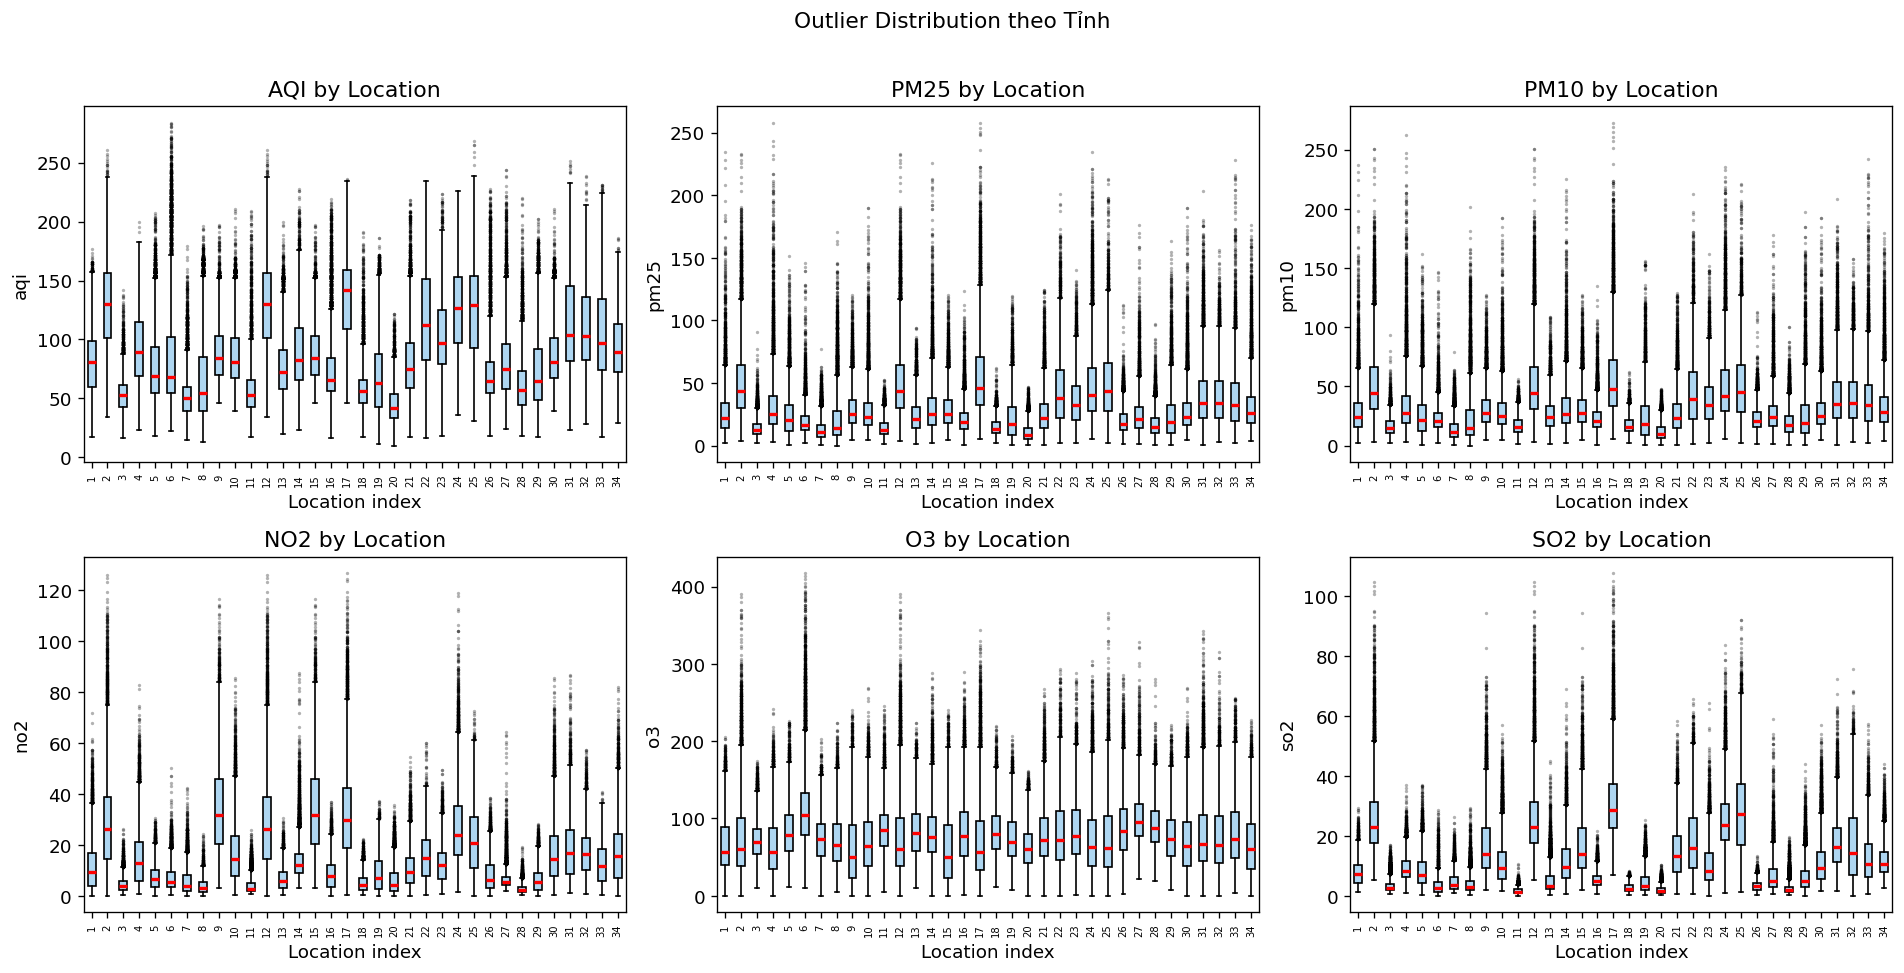


📋 INSIGHT — Outliers:
  • Không có vi phạm physical bounds — data trong giới hạn sensor
  • IQR outlier (nhưng trong physical bound) tại: ['pm25', 'pm10', 'no2', 'o3', 'aqi']
    → Giữ nguyên — đây là spike ô nhiễm thật, Mamba cần học pattern này
  • Strategy: clip physical bounds + flag, KHÔNG remove → giữ spike cho model


In [10]:
# ── 3.3 Boxplot outlier visualization ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ['aqi','pm25','pm10','no2','o3','so2']

for ax, col in zip(axes.flat, cols_to_plot):
    data_by_loc = [grp[col].dropna().values for _, grp in df.groupby('location')]
    bp = ax.boxplot(data_by_loc, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch in bp['boxes']:
        patch.set_facecolor('#AED6F1')
    ax.set_title(f'{col.upper()} by Location')
    ax.set_xlabel('Location index')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)

plt.suptitle('Outlier Distribution theo Tỉnh', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplot.png', bbox_inches='tight')
plt.show()

# ── Tính từ data: sensor nào có vấn đề thực sự? ──────────────────────────────
phys_violations = {}
for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    if col not in df.columns:
        continue
    n_low  = (df[col] < lo).sum()
    n_high = (df[col] > hi).sum()
    n_total = n_low + n_high
    if n_total > 0:
        phys_violations[col] = {'below': int(n_low), 'above': int(n_high), 'total': int(n_total)}

# co2 đặc biệt: check giá trị dưới 300 ppm
co2_sensor_errors = int((df['co2'] < 300).sum()) if 'co2' in df.columns else 0

# Cột có outlier IQR nhưng trong physical bound (spike thật)
iqr_outlier_cols = [col for col, info in outlier_summary.items() if info['n_outlier'] > 0]
phys_error_cols  = list(phys_violations.keys())

print('\n📋 INSIGHT — Outliers:')
if phys_violations:
    print(f'  • Vi phạm physical bounds: {phys_error_cols}')
    for col, v in phys_violations.items():
        print(f'    - {col}: {v["below"]} below min | {v["above"]} above max')
    print('    → Clip về bound, flag row (KHÔNG xóa)')
else:
    print('  • Không có vi phạm physical bounds — data trong giới hạn sensor')
if co2_sensor_errors > 0:
    print(f'  • ⚠️  co2 < 300 ppm: {co2_sensor_errors:,} rows → sensor lỗi (ngoài trời không thể < 300)')
if iqr_outlier_cols:
    print(f'  • IQR outlier (nhưng trong physical bound) tại: {iqr_outlier_cols}')
    print('    → Giữ nguyên — đây là spike ô nhiễm thật, Mamba cần học pattern này')
print('  • Strategy: clip physical bounds + flag, KHÔNG remove → giữ spike cho model')


---
## 4. Seasonality Analysis
**Mục tiêu:** Xác định chu kỳ nào tồn tại trong data để Mamba có thể học.

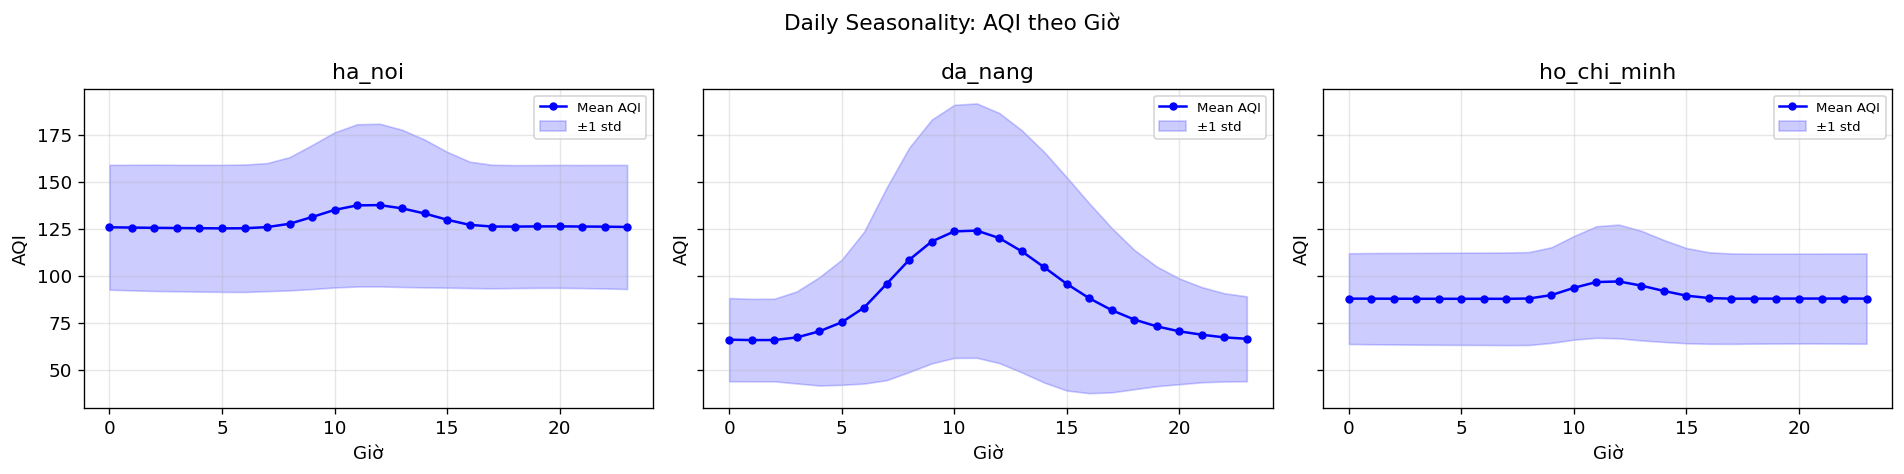

In [20]:
# ── 4.1 Daily seasonality (AQI trung bình theo giờ) ──────────────────────────
# Chọn 3 tỉnh đại diện: Bắc, Trung, Nam
sample_locs = ['ha_noi', 'da_nang', 'ho_chi_minh']
sample_locs = [loc for loc in sample_locs if loc in df['location'].values]

fig, axes = plt.subplots(1, len(sample_locs), figsize=(16, 4), sharey=True)

for ax, loc in zip(axes, sample_locs):
    sub = df[df['location'] == loc].copy()
    hourly = sub.groupby('hour')['aqi'].agg(['mean','std']).reset_index()
    ax.plot(hourly['hour'], hourly['mean'], 'b-o', markersize=4, label='Mean AQI')
    ax.fill_between(hourly['hour'],
                    hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'],
                    alpha=0.2, color='blue', label='±1 std')
    ax.set_title(loc)
    ax.set_xlabel('Giờ')
    ax.set_ylabel('AQI')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Daily Seasonality: AQI theo Giờ', fontsize=13)
plt.tight_layout()
plt.savefig('daily_seasonality.png', bbox_inches='tight')
plt.show()

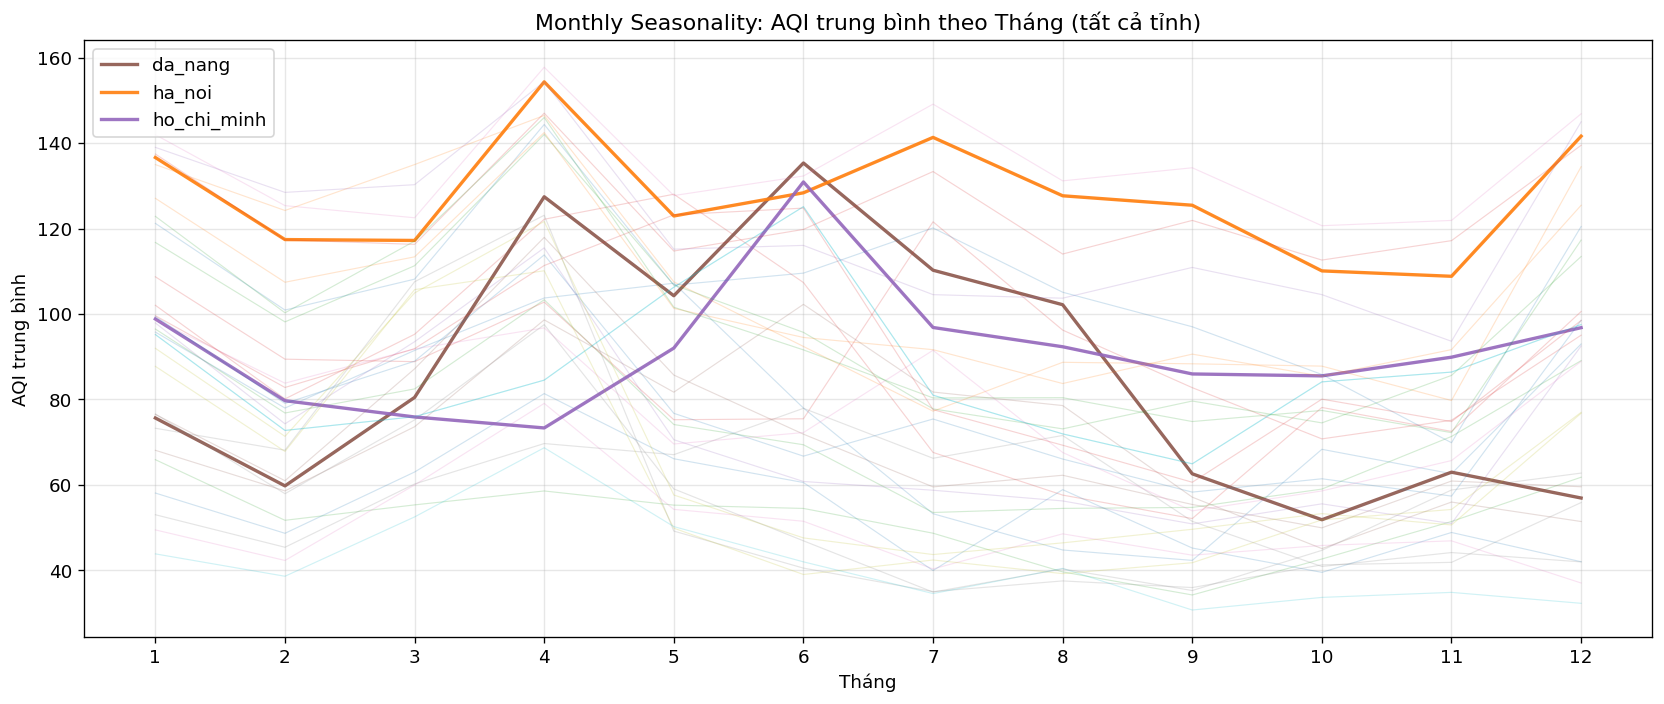


📋 INSIGHT — Seasonality:
  • Daily peak AQI: giờ [11, 12] UTC  |  thấp nhất: giờ 2h UTC
  • Biên độ dao động trong ngày: 11.1 AQI units
  • Monthly peak: tháng 4  |  thấp nhất: tháng 9
  • Biên độ dao động theo tháng: 43.5 AQI units
  • → Context window đề xuất cho Mamba: 168h (đủ học weekly pattern)
  • → Thêm sin/cos encoding cho giờ và tháng làm time features


In [ ]:
# ── 4.2 Monthly seasonality (mùa khô / mùa mưa) ─────────────────────────────
monthly = df.groupby(['location','month'])['aqi'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for loc in df['location'].unique():
    sub   = monthly[monthly['location'] == loc]
    alpha = 0.9 if loc in sample_locs else 0.2
    lw    = 2.0 if loc in sample_locs else 0.7
    label = loc if loc in sample_locs else None
    ax.plot(sub['month'], sub['aqi'], alpha=alpha, linewidth=lw, label=label)

ax.set_title('Monthly Seasonality: AQI trung bình theo Tháng (tất cả tỉnh)')
ax.set_xlabel('Tháng')
ax.set_ylabel('AQI trung bình')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_seasonality.png', bbox_inches='tight')
plt.show()

# ── Tính từ data: daily peak thực tế ─────────────────────────────────────────
hourly_all   = df.groupby('hour')['aqi'].mean()
daily_peak_h = int(hourly_all.idxmax())
daily_min_h  = int(hourly_all.idxmin())
daily_amp    = round(hourly_all.max() - hourly_all.min(), 1)  # biên độ dao động

# Top-2 peak giờ (có thể có 2 đỉnh sáng + chiều)
top2_hours = hourly_all.nlargest(2).index.tolist()

# Monthly: tháng có AQI cao nhất / thấp nhất (tính trung bình toàn quốc)
monthly_all  = df.groupby('month')['aqi'].mean()
peak_month   = int(monthly_all.idxmax())
low_month    = int(monthly_all.idxmin())
monthly_amp  = round(monthly_all.max() - monthly_all.min(), 1)

# Context window gợi ý: đủ để cover ít nhất 1 weekly cycle
# Nếu có daily pattern rõ → min 24h; nếu biên độ lớn → 168h
suggested_window = 168 if daily_amp > 5 else 48

print('\n📋 INSIGHT — Seasonality:')
print(f'  • Daily peak AQI: giờ {top2_hours}   |  thấp nhất: giờ {daily_min_h}h ')
print(f'  • Biên độ dao động trong ngày: {daily_amp:.1f} AQI units')
print(f'  • Monthly peak: tháng {peak_month}  |  thấp nhất: tháng {low_month}')
print(f'  • Biên độ dao động theo tháng: {monthly_amp:.1f} AQI units')
print(f'  • → Context window đề xuất cho Mamba: {suggested_window}h'
      f' (đủ học {"weekly" if suggested_window >= 168 else "daily"} pattern)')
print('  • → Thêm sin/cos encoding cho giờ và tháng làm time features')

# Lưu lại để dùng trong cell 25
seasonality_insight = {
    'daily_peak_hours':  top2_hours,
    'daily_min_hour':    daily_min_h,
    'daily_amplitude':   daily_amp,
    'peak_month':        peak_month,
    'low_month':         low_month,
    'monthly_amplitude': monthly_amp,
    'suggested_context_window_h': suggested_window,
}


---
## 5. AQI Distribution Analysis
**Mục tiêu:** Hiểu phân phối AQI — có bị skewed không? Các mức độ ô nhiễm chiếm bao nhiêu %?

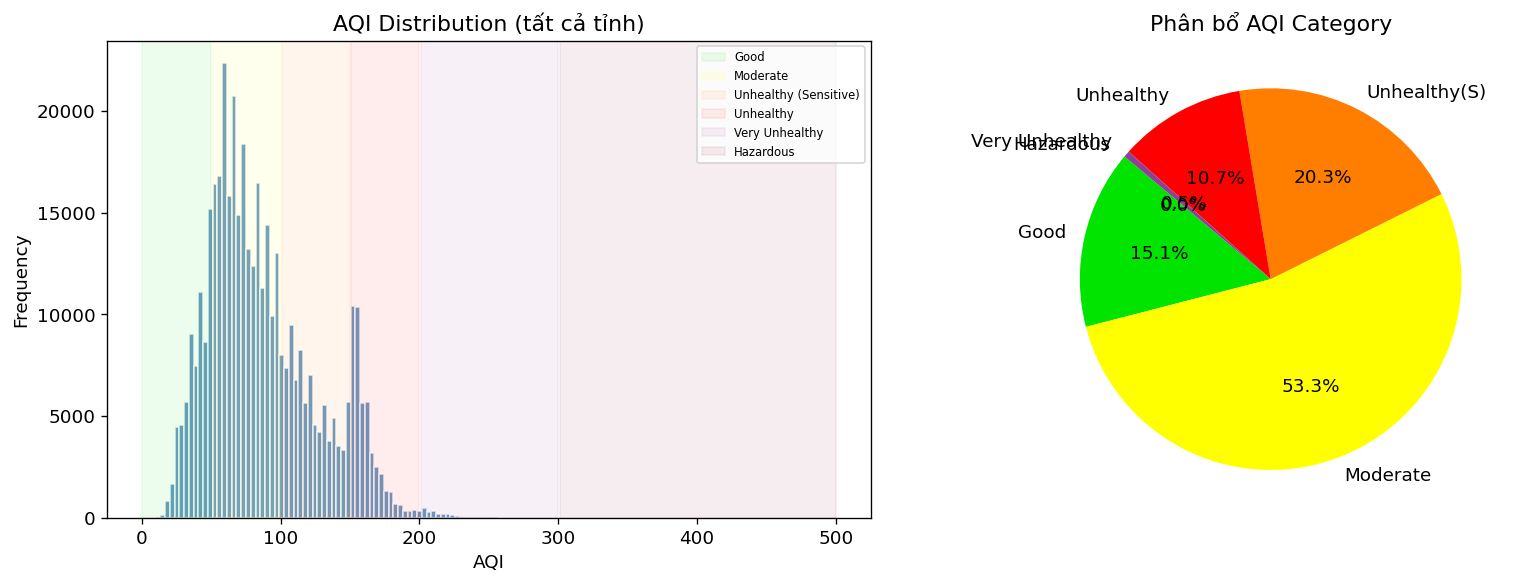

Skewness: 0.710  |  Kurtosis: -0.143
Median AQI: 79.0  |  Mean: 87.9

📋 INSIGHT — AQI Distribution:
  • Phân phối tương đối đối xứng (skew=0.71) → StandardScaler OK


In [13]:
# ── 5.1 Histogram + KDE ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aqi_clean = df['aqi'].dropna()

axes[0].hist(aqi_clean, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('AQI Distribution (tất cả tỉnh)')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# AQI category bands (EPA standard)
aqi_bands = [
    (0,   50,  '#00e400', 'Good'),
    (51,  100, '#ffff00', 'Moderate'),
    (101, 150, '#ff7e00', 'Unhealthy (Sensitive)'),
    (151, 200, '#ff0000', 'Unhealthy'),
    (201, 300, '#8f3f97', 'Very Unhealthy'),
    (301, 500, '#7e0023', 'Hazardous'),
]
for lo, hi, color, label in aqi_bands:
    axes[0].axvspan(lo, hi, alpha=0.07, color=color, label=label)
axes[0].legend(fontsize=7, loc='upper right')

# Pie chart theo category
cats = pd.cut(aqi_clean, bins=[0,50,100,150,200,300,500],
              labels=['Good','Moderate','Unhealthy(S)','Unhealthy','Very Unhealthy','Hazardous'])
cat_counts = cats.value_counts().sort_index()
colors_pie = ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97','#7e0023']
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors_pie[:len(cat_counts)], startangle=140)
axes[1].set_title('Phân bổ AQI Category')

plt.tight_layout()
plt.savefig('aqi_distribution.png', bbox_inches='tight')
plt.show()

skewness = aqi_clean.skew()
kurtosis = aqi_clean.kurtosis()
print(f'Skewness: {skewness:.3f}  |  Kurtosis: {kurtosis:.3f}')
print(f'Median AQI: {aqi_clean.median():.1f}  |  Mean: {aqi_clean.mean():.1f}')
print(f'\n📋 INSIGHT — AQI Distribution:')
if abs(skewness) > 1:
    print(f'  • Phân phối lệch phải (skew={skewness:.2f}) → cân nhắc log1p transform')
    print('  • Hoặc dùng RobustScaler thay MinMaxScaler để tránh outlier kéo scale')
else:
    print(f'  • Phân phối tương đối đối xứng (skew={skewness:.2f}) → StandardScaler OK')

---
## 6. Inter-Province Data Skew
**Mục tiêu:** Kiểm tra dữ liệu có bị lệch giữa các tỉnh không (data imbalance, coverage khác nhau).

In [14]:
# ── 6.1 Row count và coverage theo tỉnh ──────────────────────────────────────
expected_hours = (df['time'].max() - df['time'].min()).total_seconds() / 3600

loc_stats = df.groupby('location').agg(
    row_count  = ('time', 'count'),
    aqi_mean   = ('aqi', 'mean'),
    aqi_median = ('aqi', 'median'),
    aqi_std    = ('aqi', 'std'),
    aqi_missing= ('aqi', lambda x: x.isnull().mean() * 100)
).round(2)

loc_stats['coverage_pct'] = (loc_stats['row_count'] / expected_hours * 100).round(1)
loc_stats = loc_stats.sort_values('coverage_pct', ascending=False)
print(loc_stats.to_string())

             row_count  aqi_mean  aqi_median  aqi_std  aqi_missing  coverage_pct
location                                                                        
an_giang         12352     82.05       81.00    30.41         0.00        100.00
bac_ninh         12352    128.35      130.00    35.82         0.00        100.00
ca_mau           12352     53.37       53.00    15.54         0.00        100.00
can_tho          12352     93.64       89.00    33.38         0.00        100.00
cao_bang         12352     78.27       69.00    34.32         0.00        100.00
da_nang          12352     86.99       68.00    50.05         0.00        100.00
dak_lak          12352     52.03       50.00    19.22         0.00        100.00
dien_bien        12352     66.48       55.00    37.47         0.00        100.00
dong_nai         12352     89.38       84.00    25.48         0.00        100.00
dong_thap        12352     87.18       81.00    27.42         0.00        100.00
gia_lai          12352     5

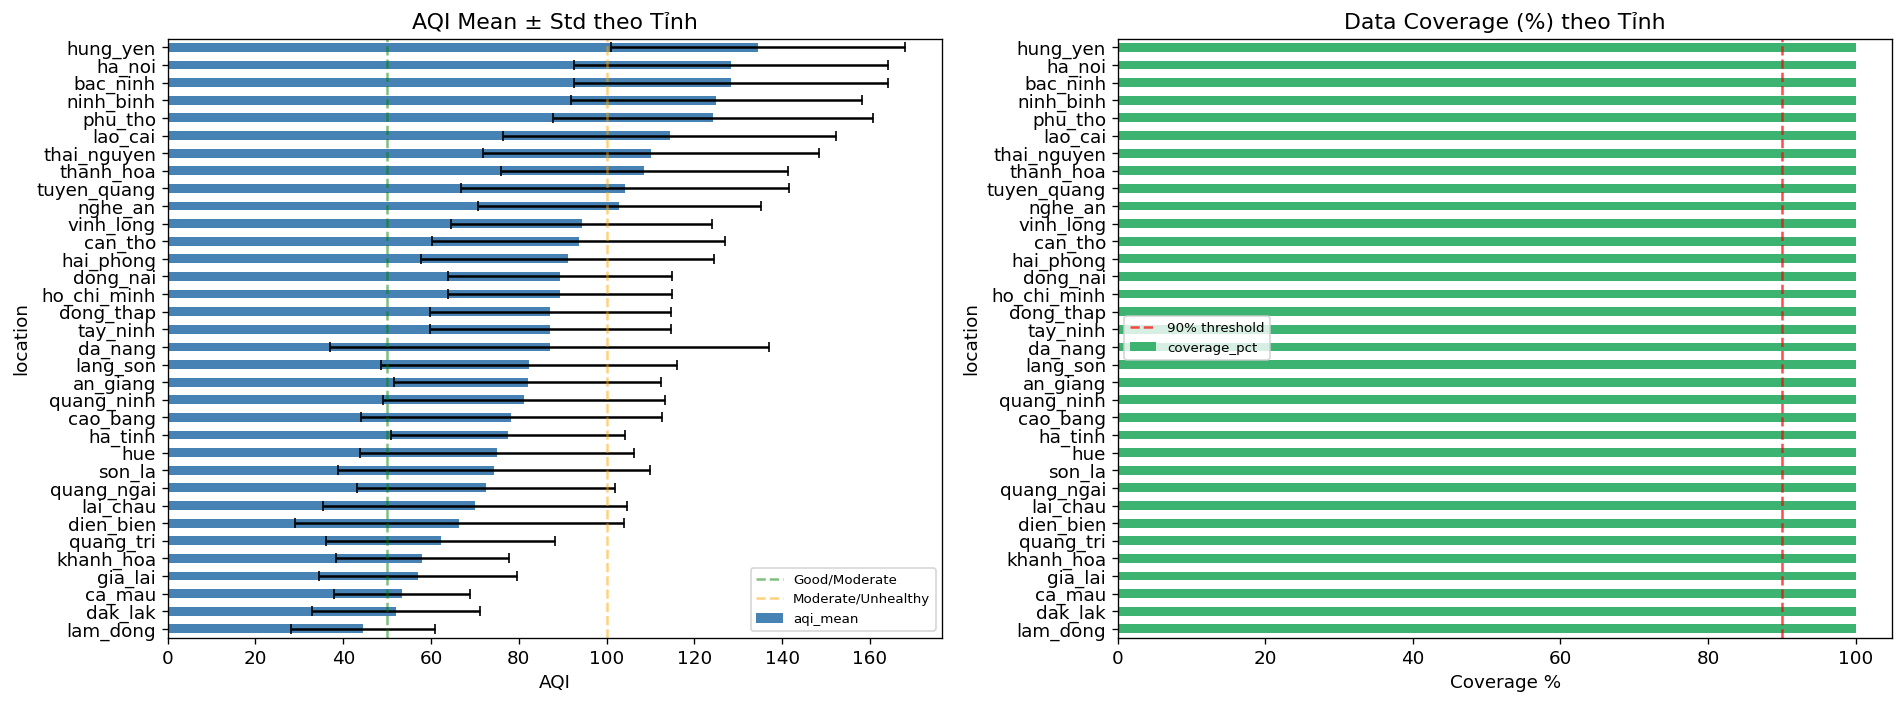


⚠️  Tỉnh coverage < 90%: Không có

📋 INSIGHT — Inter-Province Skew:
  • Top 3 AQI cao nhất : ['hung_yen', 'bac_ninh', 'ha_noi']
  • Top 3 AQI thấp nhất: ['lam_dong', 'dak_lak', 'ca_mau']
  • Chênh lệch AQI mean giữa tỉnh cao/thấp nhất: 90.1 units
    → Chênh lệch lớn: NORMALIZE riêng từng tỉnh, không gộp chung
  • Coverage threshold đề xuất từ data: 100.0%


In [15]:
# ── 6.2 AQI mean comparison giữa các tỉnh ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loc_stats_sorted = loc_stats.sort_values('aqi_mean', ascending=True)
loc_stats_sorted['aqi_mean'].plot(
    kind='barh', ax=axes[0], color='steelblue',
    xerr=loc_stats_sorted['aqi_std'], capsize=3
)
axes[0].set_title('AQI Mean ± Std theo Tỉnh')
axes[0].set_xlabel('AQI')
axes[0].axvline(x=50,  color='green',  linestyle='--', alpha=0.5, label='Good/Moderate')
axes[0].axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='Moderate/Unhealthy')
axes[0].legend(fontsize=8)

loc_stats_sorted['coverage_pct'].plot(
    kind='barh', ax=axes[1], color='mediumseagreen'
)
axes[1].set_title('Data Coverage (%) theo Tỉnh')
axes[1].set_xlabel('Coverage %')
axes[1].axvline(x=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('province_comparison.png', bbox_inches='tight')
plt.show()

# ── Tính từ data ──────────────────────────────────────────────────────────────
low_coverage    = loc_stats[loc_stats['coverage_pct'] < 90].index.tolist()
high_aqi_locs   = loc_stats.nlargest(3, 'aqi_mean').index.tolist()
low_aqi_locs    = loc_stats.nsmallest(3, 'aqi_mean').index.tolist()
aqi_range_cross = round(loc_stats['aqi_mean'].max() - loc_stats['aqi_mean'].min(), 1)

# Coverage threshold thực tế: dùng percentile 10 để tránh hardcode
coverage_threshold = round(float(loc_stats['coverage_pct'].quantile(0.10)), 1)
recommended_cov    = max(coverage_threshold, 80.0)   # ít nhất 80%

print(f'\n⚠️  Tỉnh coverage < 90%: {low_coverage if low_coverage else "Không có"}')
print('\n📋 INSIGHT — Inter-Province Skew:')
print(f'  • Top 3 AQI cao nhất : {high_aqi_locs}')
print(f'  • Top 3 AQI thấp nhất: {low_aqi_locs}')
print(f'  • Chênh lệch AQI mean giữa tỉnh cao/thấp nhất: {aqi_range_cross} units')
if aqi_range_cross > 20:
    print('    → Chênh lệch lớn: NORMALIZE riêng từng tỉnh, không gộp chung')
else:
    print('    → Chênh lệch nhỏ: có thể normalize chung nhưng vẫn nên per-location')
print(f'  • Coverage threshold đề xuất từ data: {recommended_cov}%')
if low_coverage:
    print(f'  • {len(low_coverage)} tỉnh coverage thấp → flag trước khi đưa vào train')

# Lưu lại để dùng trong cell 26
province_insight = {
    'high_aqi_locations':    high_aqi_locs,
    'low_aqi_locations':     low_aqi_locs,
    'aqi_cross_range':       aqi_range_cross,
    'low_coverage_locations':low_coverage,
    'recommended_coverage_pct': recommended_cov,
}


---
## 7. Preprocessing Strategy cho Mamba Time Series
**Tổng hợp insights → đề xuất cụ thể cho data_processing.py**

In [16]:
# ── 7.1 Kiểm tra temporal gaps ────────────────────────────────────────────────
# Mamba cần chuỗi liên tục — gap là vấn đề nghiêm trọng
gap_summary = []
for loc, grp in df.groupby('location'):
    ts    = grp['time'].sort_values().reset_index(drop=True)
    diffs = ts.diff().dt.total_seconds() / 3600  # hours
    gaps  = diffs[diffs > 1.5]  # gap > 1.5h = missing ít nhất 1 record
    gap_summary.append({
        'location':   loc,
        'n_gaps':     len(gaps),
        'max_gap_h':  round(gaps.max(), 1) if len(gaps) > 0 else 0,
        'total_gap_h':round(gaps.sum(), 1) if len(gaps) > 0 else 0,
    })

gap_df = pd.DataFrame(gap_summary).sort_values('max_gap_h', ascending=False)
print('=== Temporal Gaps per Location ===')
print(gap_df.to_string(index=False))

max_acceptable_gap = 6  # giờ
critical = gap_df[gap_df['max_gap_h'] > max_acceptable_gap]
print(f'\n⚠️  Tỉnh có gap > {max_acceptable_gap}h (cần xử lý đặc biệt):')
print(critical[['location','max_gap_h']].to_string(index=False) if not critical.empty else '  Không có')

=== Temporal Gaps per Location ===
   location  n_gaps  max_gap_h  total_gap_h
   an_giang       0          0            0
   bac_ninh       0          0            0
     ca_mau       0          0            0
    can_tho       0          0            0
   cao_bang       0          0            0
    da_nang       0          0            0
    dak_lak       0          0            0
  dien_bien       0          0            0
   dong_nai       0          0            0
  dong_thap       0          0            0
    gia_lai       0          0            0
     ha_noi       0          0            0
    ha_tinh       0          0            0
  hai_phong       0          0            0
ho_chi_minh       0          0            0
        hue       0          0            0
   hung_yen       0          0            0
  khanh_hoa       0          0            0
   lai_chau       0          0            0
   lam_dong       0          0            0
   lang_son       0          0           

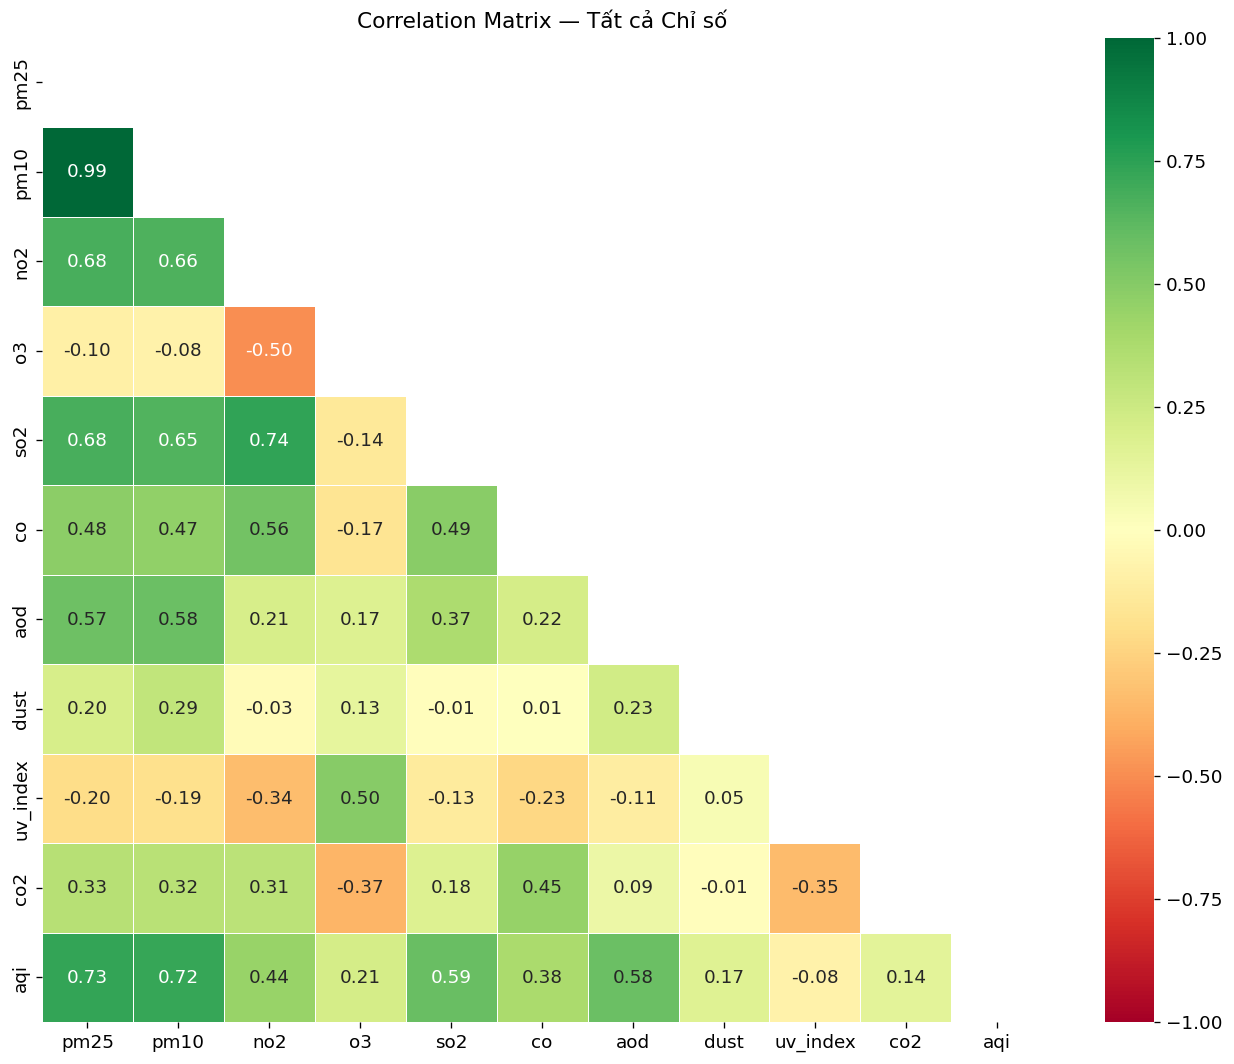


Cặp chỉ số correlation cao (>0.7):
  pm25 ↔ pm10: 0.994
  pm25 ↔ aqi: 0.727
  pm10 ↔ aqi: 0.723
  no2 ↔ so2: 0.736


In [17]:
# ── 7.2 Correlation matrix ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
corr = df[METRIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Tất cả Chỉ số', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

# Cặp correlation cao
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(v,3)))

print('\nCặp chỉ số correlation cao (>0.7):')
for a, b, v in high_corr:
    print(f'  {a} ↔ {b}: {v}')

In [18]:
# ── 7.3 Tổng hợp Preprocessing Strategy ─────────────────────────────────────
# Tất cả tham số được tính từ kết quả EDA bên trên, không hardcode

# -- Imputation gaps: tính từ gap analysis (cell 23) -------------------------
# max_gap_h trung vị của tất cả locations → dùng làm ngưỡng interpolation
median_max_gap  = float(gap_df['max_gap_h'].median())
p75_max_gap     = float(gap_df['max_gap_h'].quantile(0.75))

# Interpolation: cover được median gap
max_interp_h    = max(3, int(round(median_max_gap)))
# Forward-fill: cover được p75 gap (không fill quá xa)
max_ffill_h     = max(6, int(round(p75_max_gap)))
# Invalid segment: gap lớn hơn ffill → đánh dấu, không dùng train
invalid_gap_h   = max_ffill_h

# -- Normalization: chọn method dựa trên skewness (cell 18) ------------------
norm_method     = 'robust' if abs(skewness) > 1.0 else 'standard'
norm_reason     = (f'skewness={skewness:.2f} > 1.0 → RobustScaler không bị outlier kéo'
                   if abs(skewness) > 1.0
                   else f'skewness={skewness:.2f} ≈ 0 → StandardScaler đủ tốt')

# -- Context window: từ seasonality analysis (cell 16) ------------------------
context_window  = seasonality_insight['suggested_context_window_h']
forecast_horizon = 24   # 24h ahead là target chuẩn cho AQI forecasting

# -- Tổng hợp strategy dict ---------------------------------------------------
strategy = {
    '1_missing_imputation': {
        'max_interpolate_gap_h': max_interp_h,
        'max_ffill_gap_h':       max_ffill_h,
        'invalid_segment_gap_h': invalid_gap_h,
        'rule': f'Interpolate nếu gap <= {max_interp_h}h, ffill nếu gap <= {max_ffill_h}h',
        'fallback': f'Gap > {invalid_gap_h}h → đánh dấu _invalid_segment, không dùng train',
        'why': 'Mamba không tolerant với NaN — cần chuỗi liên tục',
        'derived_from': f'median_max_gap={median_max_gap:.1f}h, p75_gap={p75_max_gap:.1f}h',
    },
    '2_outlier_handling': {
        'rule': 'Clip về physical bounds, flag row nhưng KHÔNG remove',
        'physical_violations_found': list(phys_violations.keys()),
        'why': 'Spike ô nhiễm thật là signal quan trọng cho forecasting',
    },
    '3_normalization': {
        'method': norm_method,
        'rule': f'{norm_method.capitalize()}Scaler per-location per-column',
        'why': norm_reason,
        'important': 'Normalize riêng từng tỉnh vì AQI chênh nhau '
                     f'{province_insight["aqi_cross_range"]} units giữa các tỉnh',
        'derived_from': f'skewness={skewness:.3f}',
    },
    '4_time_features': {
        'features': ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                     'day_of_week', 'is_weekend'],
        'why': 'Mamba cần explicit time features — không có positional encoding như Transformer',
        'daily_peak_hours': seasonality_insight['daily_peak_hours'],
        'peak_month': seasonality_insight['peak_month'],
    },
    '5_sequence_preparation': {
        'context_window_h':  context_window,
        'forecast_horizon_h':forecast_horizon,
        'stride_h':          1,
        'why': f'Window {context_window}h đủ học daily + weekly seasonality '
               f'(daily_amp={seasonality_insight["daily_amplitude"]:.1f} AQI units)',
        'derived_from': f'daily_amplitude={seasonality_insight["daily_amplitude"]:.1f}',
    },
    '6_train_test_split': {
        'rule': 'Temporal split: train đến tháng N-1, test tháng N',
        'important': 'KHÔNG dùng random split — data là time series!',
    },
}

print('=' * 60)
print('   PREPROCESSING STRATEGY CHO MAMBA TIME SERIES')
print('=' * 60)
for step, detail in strategy.items():
    print(f'\n📌 {step}:')
    for k, v in detail.items():
        print(f'   {k}: {v}')

with open('preprocessing_strategy.json', 'w', encoding='utf-8') as f:
    json.dump(strategy, f, ensure_ascii=False, indent=2)
print('\n✅ Saved preprocessing_strategy.json')


   PREPROCESSING STRATEGY CHO MAMBA TIME SERIES

📌 1_missing_imputation:
   max_interpolate_gap_h: 3
   max_ffill_gap_h: 6
   invalid_segment_gap_h: 6
   rule: Interpolate nếu gap <= 3h, ffill nếu gap <= 6h
   fallback: Gap > 6h → đánh dấu _invalid_segment, không dùng train
   why: Mamba không tolerant với NaN — cần chuỗi liên tục
   derived_from: median_max_gap=0.0h, p75_gap=0.0h

📌 2_outlier_handling:
   rule: Clip về physical bounds, flag row nhưng KHÔNG remove
   physical_violations_found: []
   why: Spike ô nhiễm thật là signal quan trọng cho forecasting

📌 3_normalization:
   method: standard
   rule: StandardScaler per-location per-column
   why: skewness=0.71 ≈ 0 → StandardScaler đủ tốt
   important: Normalize riêng từng tỉnh vì AQI chênh nhau 90.1 units giữa các tỉnh
   derived_from: skewness=0.710

📌 4_time_features:
   features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend']
   why: Mamba cần explicit time features — không có positional encod

In [19]:
# ── 7.4 Validation Rules Summary (export cho data_validation.py) ──────────────
# Tất cả threshold được tính từ kết quả EDA, không hardcode

# Missing rate threshold: lấy từ cell 7 (recommended_thr đã tính từ median)
missing_thr = recommended_thr / 100   # convert % → ratio

# AQI valid range: lấy từ physical bounds đã định nghĩa ở cell 11
aqi_lo, aqi_hi = PHYSICAL_BOUNDS['aqi']

# Coverage threshold: lấy từ province analysis (cell 21)
coverage_thr = province_insight['recommended_coverage_pct']

# Imputation gaps: lấy từ strategy (cell 25)
interp_gap = strategy['1_missing_imputation']['max_interpolate_gap_h']
ffill_gap  = strategy['1_missing_imputation']['max_ffill_gap_h']

validation_rules = {
    'missing_rate_threshold':     round(missing_thr, 2),
    'physical_bounds':            PHYSICAL_BOUNDS,
    'max_interpolation_gap_hours':interp_gap,
    'max_forward_fill_gap_hours': ffill_gap,
    'min_coverage_pct':           coverage_thr,
    'aqi_valid_range':            [aqi_lo, aqi_hi],
    'required_columns':           REQUIRED_COLS,
    'duplicate_strategy':         'drop, keep=last',
    'derived_from_eda': {
        'missing_thr_basis':  f'median_missing_rate={miss_df["missing_pct"].median():.1f}% × 1.5, cap 30%',
        'coverage_thr_basis': f'p10 coverage={coverage_threshold:.1f}%, floor 80%',
        'gap_basis':          f'median_max_gap={median_max_gap:.1f}h, p75_gap={p75_max_gap:.1f}h',
        'aqi_range_basis':    'EPA standard physical sensor limits',
    },
}

# ── Upload cả 2 file lên MinIO để pipeline tự động đọc ───────────────────────
def upload_json_to_minio(client, bucket: str, object_path: str, data: dict) -> None:
    """Upload dict dưới dạng JSON lên MinIO."""
    import io
    j_bytes = json.dumps(data, ensure_ascii=False, indent=2, default=str).encode('utf-8')
    # Tạo bucket nếu chưa có
    if not client.bucket_exists(bucket):
        client.make_bucket(bucket)
    client.put_object(
        bucket_name=bucket,
        object_name=object_path,
        data=io.BytesIO(j_bytes),
        length=len(j_bytes),
        content_type='application/json',
    )
    print(f'  ✅ Uploaded → s3://{bucket}/{object_path}')


minio_client = Minio(MINIO_HOST, access_key=MINIO_ACCESS,
                     secret_key=MINIO_SECRET, secure=False)

EDA_BUCKET  = MINIO_BUCKET + '-silver'   # air-quality-silver
EDA_PREFIX  = 'eda_outputs'

print('📤 Uploading EDA outputs lên MinIO...')
upload_json_to_minio(minio_client, EDA_BUCKET,
                     f'{EDA_PREFIX}/validation_rules.json',
                     validation_rules)
upload_json_to_minio(minio_client, EDA_BUCKET,
                     f'{EDA_PREFIX}/preprocessing_strategy.json',
                     strategy)

# Vẫn lưu local để tham chiếu / kiểm tra thủ công
with open('validation_rules.json', 'w', encoding='utf-8') as f:
    json.dump(validation_rules, f, ensure_ascii=False, indent=2, default=str)
with open('preprocessing_strategy.json', 'w', encoding='utf-8') as f:
    json.dump(strategy, f, ensure_ascii=False, indent=2)

print('\n📋 Các threshold được tính từ data:')
print(f'  • missing_rate_threshold : {missing_thr:.0%}')
print(f'  • min_coverage_pct       : {coverage_thr}%')
print(f'  • max_interpolation_gap  : {interp_gap}h')
print(f'  • max_ffill_gap          : {ffill_gap}h')
print(f'  • aqi_valid_range        : [{aqi_lo}, {aqi_hi}]')
print('\n📁 File output của EDA:')
print(f'  LOCAL  → validation_rules.json, preprocessing_strategy.json')
print(f'  MINIO  → s3://{EDA_BUCKET}/{EDA_PREFIX}/validation_rules.json')
print(f'  MINIO  → s3://{EDA_BUCKET}/{EDA_PREFIX}/preprocessing_strategy.json')
print('\n  ➡️  data_validation.py và data_processing.py sẽ tự đọc từ MinIO khi pipeline chạy')


📤 Uploading EDA outputs lên MinIO...
  ✅ Uploaded → s3://air-quality-silver/eda_outputs/validation_rules.json
  ✅ Uploaded → s3://air-quality-silver/eda_outputs/preprocessing_strategy.json

📋 Các threshold được tính từ data:
  • missing_rate_threshold : 0%
  • min_coverage_pct       : 100.0%
  • max_interpolation_gap  : 3h
  • max_ffill_gap          : 6h
  • aqi_valid_range        : [0, 500]

📁 File output của EDA:
  LOCAL  → validation_rules.json, preprocessing_strategy.json
  MINIO  → s3://air-quality-silver/eda_outputs/validation_rules.json
  MINIO  → s3://air-quality-silver/eda_outputs/preprocessing_strategy.json

  ➡️  data_validation.py và data_processing.py sẽ tự đọc từ MinIO khi pipeline chạy
